In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import plotly.express as px
from mplsoccer import Pitch, VerticalPitch, FontManager, Sbopen
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
pd.set_option('display.max_columns', None)

In [19]:
events = pd.read_csv("../data/raw/whoscored/WhoScored/ENG-Premier League/2025/events/events.csv")
print(events.dtypes)
print(events.info())
print(events.shape)
print(events.columns)

C:\Users\oukan\AppData\Local\Temp\ipykernel_27428\552687951.py:1: DtypeWarning: Columns (0: is_own_goal) have mixed types. Specify dtype option on import or set low_memory=False.
  events = pd.read_csv("../data/raw/whoscored/WhoScored/ENG-Premier League/2025/events/events.csv")


Unnamed: 0                  int64
level_0                     int64
index                       int64
game                          str
game_id                     int64
period                        str
minute                      int64
second                    float64
expanded_minute             int64
type                          str
outcome_type                  str
team_id                     int64
team                          str
player_id                 float64
player                        str
x                         float64
y                         float64
end_x                     float64
end_y                     float64
goal_mouth_y              float64
goal_mouth_z              float64
blocked_x                 float64
blocked_y                 float64
qualifiers                    str
is_touch                     bool
is_shot                    object
is_goal                    object
card_type                     str
related_event_id          float64
related_player

In [20]:
def value_counts_by_column(df):
    return {
        column: df[column].value_counts(dropna=False)
        for column in df.columns
    }

counts = value_counts_by_column(events)
display(counts)

{'Unnamed: 0': Unnamed: 0
 0         1
 1         1
 2         1
 3         1
 4         1
          ..
 577879    1
 577880    1
 577881    1
 577882    1
 577883    1
 Name: count, Length: 577884, dtype: int64,
 'level_0': level_0
 0         1
 1         1
 2         1
 3         1
 4         1
          ..
 577879    1
 577880    1
 577881    1
 577882    1
 577883    1
 Name: count, Length: 577884, dtype: int64,
 'index': index
 0       380
 1       380
 2       380
 3       380
 4       380
        ... 
 1721      3
 1722      3
 1723      3
 1724      2
 1725      2
 Name: count, Length: 1726, dtype: int64,
 'game': game
 2025-12-30 Nottingham Forest-Everton     1726
 2026-03-14 West Ham-Manchester City      1726
 2026-04-12 Chelsea-Manchester City       1724
 2025-10-25 Manchester United-Brighton    1720
 2026-01-31 Chelsea-West Ham              1720
                                          ... 
 2025-11-30 Chelsea-Arsenal               1332
 2026-03-22 Newcastle-Sunderland    

In [21]:
print(events['type'].value_counts())
print(events['outcome_type'].value_counts())


type
Pass               362739
BallRecovery        30575
BallTouch           26492
Aerial              24008
Clearance           21134
Foul                16452
TakeOn              13511
Tackle              12670
CornerAwarded        7598
Dispossessed         6575
Interception         6289
BlockedPass          5626
Challenge            5213
SavedShot            4978
Save                 4899
KeeperPickup         4424
MissedShots          3309
SubstitutionOff      3132
SubstitutionOn       3132
End                  2280
Card                 1532
Start                1520
OffsideGiven         1175
OffsidePass          1175
OffsideProvoked      1175
FormationChange      1129
Goal                 1045
FormationSet          760
Claim                 668
Error                 650
ShieldBallOpp         540
Punch                 494
KeeperSweeper         479
ShotOnPost            211
Smother                98
PenaltyFaced           92
GoodSkill              68
ChanceMissed           23
CrossNo

In [22]:
interceptions = events[events['type'] == 'BallRecovery']
p_i = interceptions.groupby('player')['type'].count().sort_values(ascending=False)
display(p_i)

player
Elliot Anderson          306
André                    212
Alex Scott               195
João Gomes               194
Adrien Truffert          188
                        ... 
Sam Byram                  1
Jamaldeen Jimoh-Aloba      1
Sasa Kalajdzic             1
Tom Edozie                 1
Hákon Valdimarsson         1
Name: type, Length: 515, dtype: int64

In [23]:
mainoo = events[events['player'] == 'Kobbie Mainoo']
display(mainoo.head())

,Unnamed: 0,level_0,index,game,game_id,period,minute,second,expanded_minute,type,outcome_type,team_id,team,player_id,player,x,y,end_x,end_y,goal_mouth_y,goal_mouth_z,blocked_x,blocked_y,qualifiers,is_touch,is_shot,is_goal,card_type,related_event_id,related_player_id,id,event_id,satisfied_events_types,season,league,is_own_goal
33138,33138,33138,734,2025-08-30 Manchester United-Burnley,1903146,SecondHalf,45,0.0,54,SubstitutionOn,Successful,32,Man Utd,460260.0,Kobbie Mainoo,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,"[{'type': {'value': 55, 'displayName': 'Relate...",False,NaN,NaN,NaN,441.0,343346.0,2.841048e+09,442,[213],2025,ENG-Premier League,NaN
33169,33169,33169,765,2025-08-30 Manchester United-Burnley,1903146,SecondHalf,45,46.0,54,Tackle,Successful,32,Man Utd,460260.0,Kobbie Mainoo,35.6,81.8,NaN,NaN,NaN,NaN,NaN,NaN,"[{'type': {'value': 56, 'displayName': 'Zone'}...",True,NaN,NaN,NaN,NaN,NaN,2.841050e+09,455,"[91, 143]",2025,ENG-Premier League,NaN
33196,33196,33196,792,2025-08-30 Manchester United-Burnley,1903146,SecondHalf,48,14.0,57,Pass,Successful,32,Man Utd,460260.0,Kobbie Mainoo,88.6,91.8,92.3,56.5,NaN,NaN,NaN,NaN,"[{'type': {'value': 56, 'displayName': 'Zone'}...",True,NaN,NaN,NaN,NaN,NaN,2.841055e+09,473,"[91, 119, 123, 138, 125, 40, 41, 36, 38, 217, ...",2025,ENG-Premier League,NaN
33206,33206,33206,802,2025-08-30 Manchester United-Burnley,1903146,SecondHalf,49,16.0,58,Dispossessed,Successful,32,Man Utd,460260.0,Kobbie Mainoo,66.9,89.4,NaN,NaN,NaN,NaN,NaN,NaN,"[{'type': {'value': 286, 'displayName': 'Offen...",True,NaN,NaN,NaN,NaN,NaN,2.841057e+09,483,"[91, 70]",2025,ENG-Premier League,NaN
33220,33220,33220,816,2025-08-30 Manchester United-Burnley,1903146,SecondHalf,49,54.0,58,Pass,Successful,32,Man Utd,460260.0,Kobbie Mainoo,45.4,67.8,54.5,64.5,NaN,NaN,NaN,NaN,"[{'type': {'value': 212, 'displayName': 'Lengt...",True,NaN,NaN,NaN,NaN,NaN,2.841058e+09,493,"[91, 119, 117, 30, 36, 38, 216, 218]",2025,ENG-Premier League,NaN


In [24]:
#filter mainoo tackles won
mainoo_tackles = mainoo[mainoo['type'] == 'BallRecovery']
#display(mainoo_tackles)

success = mainoo_tackles[mainoo_tackles['outcome_type'] == 'Successful']
missed = mainoo_tackles[mainoo_tackles['outcome_type'] == 'Unsuccessful']

print(mainoo_tackles['outcome_type'].value_counts())
#display(success)


outcome_type
Successful    95
Name: count, dtype: int64


In [25]:
#filter mainoo tackles won
mainoo_tackles = mainoo[mainoo['is_touch'] == True]
#display(mainoo_tackles)

success = mainoo_tackles[mainoo_tackles['outcome_type'] == 'Successful']
missed = mainoo_tackles[mainoo_tackles['outcome_type'] == 'Unsuccessful']

print(mainoo_tackles['outcome_type'].value_counts())
display(missed)


outcome_type
Successful      1171
Unsuccessful     187
Name: count, dtype: int64


,Unnamed: 0,level_0,index,game,game_id,period,minute,second,expanded_minute,type,outcome_type,team_id,team,player_id,player,x,y,end_x,end_y,goal_mouth_y,goal_mouth_z,blocked_x,blocked_y,qualifiers,is_touch,is_shot,is_goal,card_type,related_event_id,related_player_id,id,event_id,satisfied_events_types,season,league,is_own_goal
33393,33393,33393,989,2025-08-30 Manchester United-Burnley,1903146,SecondHalf,63,22.0,72,Pass,Unsuccessful,32,Man Utd,460260.0,Kobbie Mainoo,29.8,18.0,24.6,12.7,NaN,NaN,NaN,NaN,"[{'type': {'value': 141, 'displayName': 'PassE...",True,NaN,NaN,NaN,NaN,NaN,2.841084e+09,596,"[91, 118, 120, 29, 35, 38, 215, 218]",2025,ENG-Premier League,NaN
33779,33779,33779,1375,2025-08-30 Manchester United-Burnley,1903146,SecondHalf,88,46.0,97,Pass,Unsuccessful,32,Man Utd,460260.0,Kobbie Mainoo,62.6,46.6,70.4,53.1,NaN,NaN,NaN,NaN,"[{'type': {'value': 56, 'displayName': 'Zone'}...",True,NaN,NaN,NaN,NaN,NaN,2.841131e+09,839,"[91, 120, 29, 36, 37, 217, 218]",2025,ENG-Premier League,NaN
33785,33785,33785,1381,2025-08-30 Manchester United-Burnley,1903146,SecondHalf,88,58.0,97,Pass,Unsuccessful,32,Man Utd,460260.0,Kobbie Mainoo,22.1,5.8,24.2,4.8,NaN,NaN,NaN,NaN,"[{'type': {'value': 212, 'displayName': 'Lengt...",True,NaN,NaN,NaN,NaN,NaN,2.841132e+09,842,"[91, 118, 120, 29, 36, 38, 215, 218]",2025,ENG-Premier League,NaN
33800,33800,33800,1396,2025-08-30 Manchester United-Burnley,1903146,SecondHalf,90,5.0,99,Pass,Unsuccessful,32,Man Utd,460260.0,Kobbie Mainoo,35.3,19.0,52.5,15.1,NaN,NaN,NaN,NaN,"[{'type': {'value': 140, 'displayName': 'PassE...",True,NaN,NaN,NaN,NaN,NaN,2.841133e+09,857,"[91, 120, 29, 36, 38, 216, 218]",2025,ENG-Premier League,NaN
33809,33809,33809,1405,2025-08-30 Manchester United-Burnley,1903146,SecondHalf,90,17.0,99,Pass,Unsuccessful,32,Man Utd,460260.0,Kobbie Mainoo,34.1,1.9,35.3,3.6,NaN,NaN,NaN,NaN,"[{'type': {'value': 141, 'displayName': 'PassE...",True,NaN,NaN,NaN,NaN,NaN,2.841133e+09,862,"[91, 118, 120, 29, 36, 37, 216, 218]",2025,ENG-Premier League,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574570,574570,574570,994,2026-05-24 Brighton-Manchester United,1903458,SecondHalf,66,34.0,70,Pass,Unsuccessful,32,Man Utd,460260.0,Kobbie Mainoo,57.7,28.0,66.0,69.5,NaN,NaN,NaN,NaN,"[{'type': {'value': 56, 'displayName': 'Zone'}...",True,NaN,NaN,NaN,NaN,NaN,2.941360e+09,526,"[91, 120, 29, 124, 36, 37, 216, 218]",2025,ENG-Premier League,NaN
574746,574746,574746,1170,2026-05-24 Brighton-Manchester United,1903458,SecondHalf,76,15.0,80,BallTouch,Unsuccessful,32,Man Utd,460260.0,Kobbie Mainoo,60.1,68.7,NaN,NaN,NaN,NaN,NaN,NaN,"[{'type': {'value': 56, 'displayName': 'Zone'}...",True,NaN,NaN,NaN,NaN,NaN,2.941369e+09,629,"[91, 69]",2025,ENG-Premier League,NaN
574794,574794,574794,1218,2026-05-24 Brighton-Manchester United,1903458,SecondHalf,79,33.0,83,Pass,Unsuccessful,32,Man Utd,460260.0,Kobbie Mainoo,57.8,30.3,57.3,24.6,NaN,NaN,NaN,NaN,"[{'type': {'value': 56, 'displayName': 'Zone'}...",True,NaN,NaN,NaN,NaN,NaN,2.941372e+09,651,"[91, 120, 29, 35, 38, 216, 218]",2025,ENG-Premier League,NaN
574951,574951,574951,1375,2026-05-24 Brighton-Manchester United,1903458,SecondHalf,90,36.0,94,TakeOn,Unsuccessful,32,Man Utd,460260.0,Kobbie Mainoo,30.5,29.7,NaN,NaN,NaN,NaN,NaN,NaN,"[{'type': {'value': 56, 'displayName': 'Zone'}...",True,NaN,NaN,NaN,NaN,NaN,2.941384e+09,742,"[91, 53]",2025,ENG-Premier League,NaN


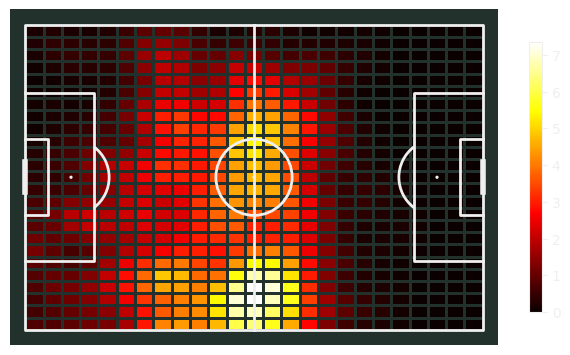

In [26]:
pitch = Pitch(pitch_type='statsbomb', line_zorder=2,
              pitch_color='#22312b', line_color='#efefef')
# specifying figure size (width, height)
fig, ax = pitch.draw()
bin_statistic = pitch.bin_statistic(success['x'], success['y'], statistic= 'count', bins=(25, 25))
bin_statistic['statistic'] = gaussian_filter(bin_statistic['statistic'], 1)
pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='hot', edgecolors='#22312b')
# Add the colorbar and format off-white
cbar = fig.colorbar(pcm, ax=ax, shrink=0.6)
cbar.outline.set_edgecolor('#efefef')
cbar.ax.yaxis.set_tick_params(color='#efefef')
ticks = plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#efefef')


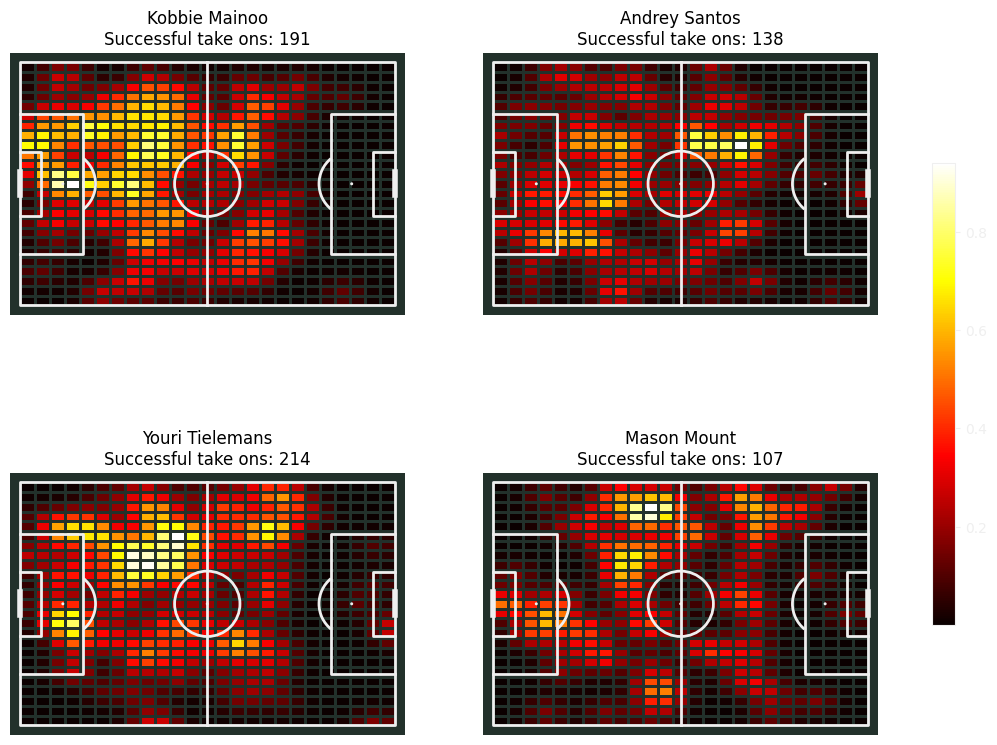

In [27]:
players = (
    "Kobbie Mainoo",
    "Andrey Santos",
    "Youri Tielemans",
    "Mason Mount",
)

def_actions = (
    "Interception",
    "BallRecovery",
    "Clearance",
    "Tackle",
    "BlockedPass",
    "Aerial")

player_events = events[
    events['player'].isin(players)
    & events['type'].isin(def_actions)
    & events['outcome_type'].eq('Successful')
].copy()

# Use 'opta' for WhoScored-style coordinates (0–100).
# Keep 'statsbomb' only if the data uses StatsBomb coordinates (120 × 80).
pitch = Pitch(
    pitch_type='opta',
    line_zorder=2,
    pitch_color='#22312b',
    line_color='#efefef',
    positional=True,
    shade_middle=False,
    positional_color='blue',
    shade_color='#f2f2f2',
)

fig, axs = pitch.draw(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    tight_layout=False,
    constrained_layout=True,
)

axs = axs.flatten()
heatmaps = []

for player_name, axis in zip(players, axs):
    player_success = player_events[
        player_events['player'].eq(player_name)
    ]

    bin_statistic = pitch.bin_statistic(
        player_success['x'],
        player_success['y'],
        statistic='count',
        bins=(25, 25),
    )

    bin_statistic['statistic'] = gaussian_filter(
        bin_statistic['statistic'],
        sigma=1,
    )

    pcm = pitch.heatmap(
        bin_statistic,
        ax=axis,
        cmap='hot',
        edgecolors='#22312b',
    )

    axis.set_title(
        f"{player_name}\nSuccessful take ons: {len(player_success)}",
        color='black',
        fontsize=12,
    )

    heatmaps.append(pcm)

# Shared colorbar
cbar = fig.colorbar(
    heatmaps[-1],
    ax=axs.tolist(),
    shrink=0.6,
)

cbar.outline.set_edgecolor('#efefef')
cbar.ax.tick_params(colors='#efefef')

plt.show()

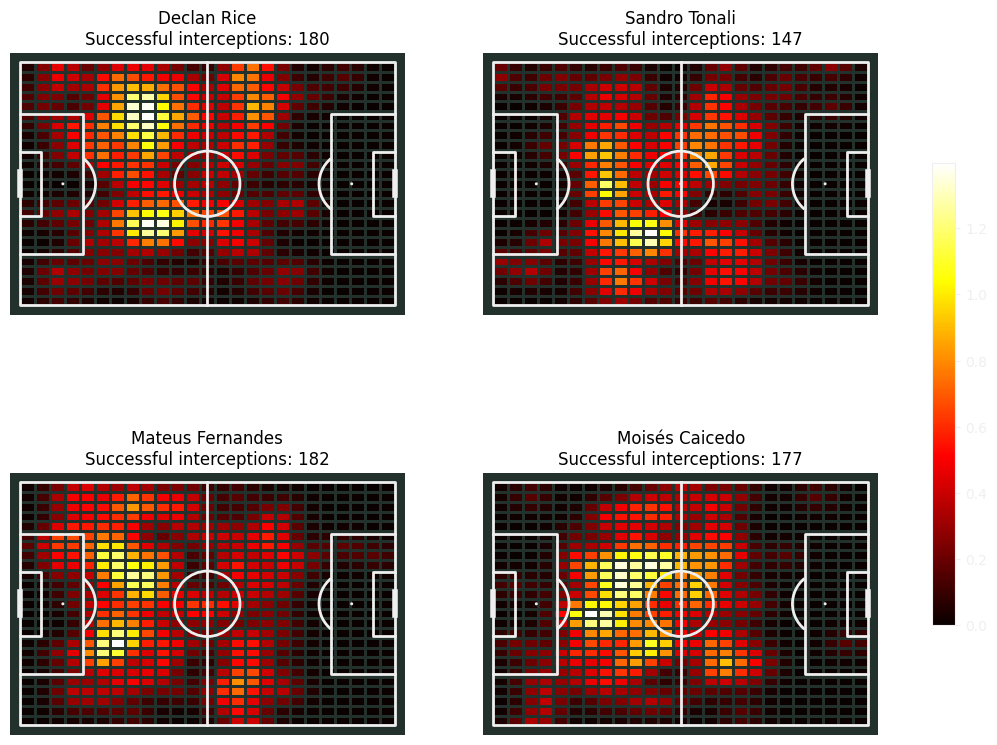

In [28]:
players = (
    "Declan Rice",
    "Sandro Tonali",
    "Mateus Fernandes",
    "Moisés Caicedo"
)

player_events = events[
    events['player'].isin(players)
    & events['type'].eq('BallRecovery')
    & events['outcome_type'].eq('Successful')
].copy()

# Use 'opta' for WhoScored-style coordinates (0–100).
# Keep 'statsbomb' only if the data uses StatsBomb coordinates (120 × 80).
pitch = Pitch(
    pitch_type='opta',
    line_zorder=2,
    pitch_color='#22312b',
    line_color='#efefef',
    positional=True,
    shade_middle=False,
    positional_color='blue',
    shade_color='#f2f2f2',
)

fig, axs = pitch.draw(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    tight_layout=False,
    constrained_layout=True,
)

axs = axs.flatten()
heatmaps = []

for player_name, axis in zip(players, axs):
    player_success = player_events[
        player_events['player'].eq(player_name)
    ]

    bin_statistic = pitch.bin_statistic(
        player_success['x'],
        player_success['y'],
        statistic='count',
        bins=(25, 25),
    )

    bin_statistic['statistic'] = gaussian_filter(
        bin_statistic['statistic'],
        sigma=1,
    )

    pcm = pitch.heatmap(
        bin_statistic,
        ax=axis,
        cmap='hot',
        edgecolors='#22312b',
    )

    axis.set_title(
        f"{player_name}\nSuccessful interceptions: {len(player_success)}",
        color='black',
        fontsize=12,
    )

    heatmaps.append(pcm)

# Shared colorbar
cbar = fig.colorbar(
    heatmaps[-1],
    ax=axs.tolist(),
    shrink=0.6,
)

cbar.outline.set_edgecolor('#efefef')
cbar.ax.tick_params(colors='#efefef')

plt.show()

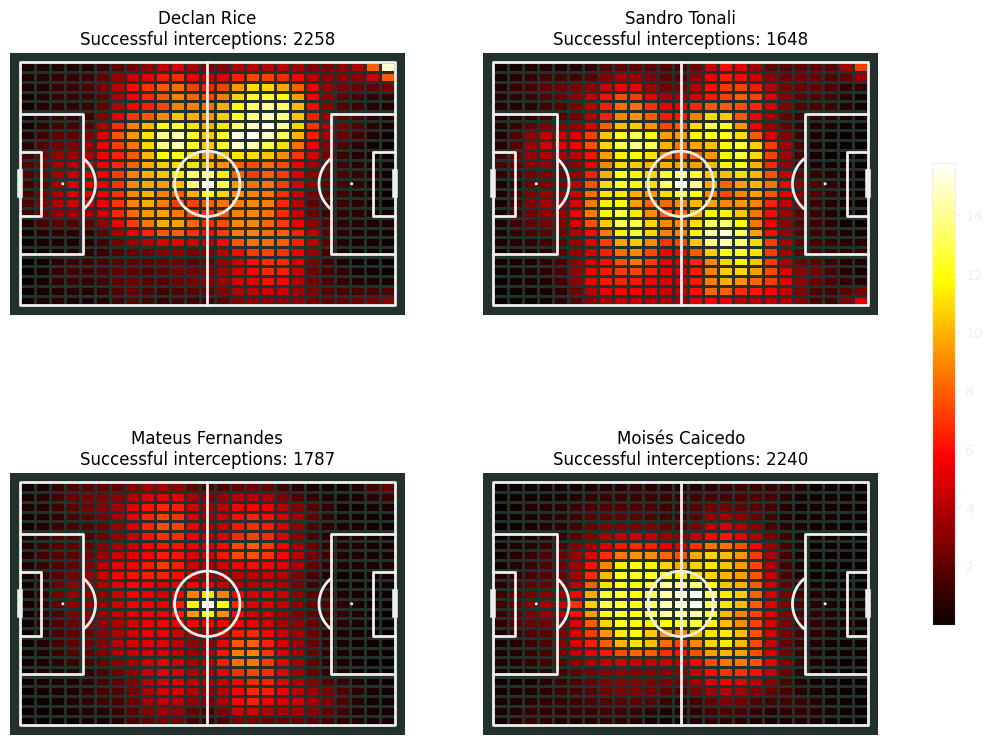

In [29]:
players = (
    "Declan Rice",
        "Sandro Tonali",
        "Mateus Fernandes",
        "Moisés Caicedo"
)

player_events = events[
    events['player'].isin(players)
    & events['is_touch'].eq(True)
    & events['outcome_type'].eq('Successful')
].copy()

# Use 'opta' for WhoScored-style coordinates (0–100).
# Keep 'statsbomb' only if the data uses StatsBomb coordinates (120 × 80).
pitch = Pitch(
    pitch_type='opta',
    line_zorder=2,
    pitch_color='#22312b',
    line_color='#efefef',
    positional=True,
    shade_middle=False,
    positional_color='blue',
    shade_color='#f2f2f2',
)

fig, axs = pitch.draw(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    tight_layout=False,
    constrained_layout=True,
)

axs = axs.flatten()
heatmaps = []

for player_name, axis in zip(players, axs):
    player_success = player_events[
        player_events['player'].eq(player_name)
    ]

    bin_statistic = pitch.bin_statistic(
        player_success['x'],
        player_success['y'],
        statistic='count',
        bins=(25, 25),
    )

    bin_statistic['statistic'] = gaussian_filter(
        bin_statistic['statistic'],
        sigma=1,
    )

    pcm = pitch.heatmap(
        bin_statistic,
        ax=axis,
        cmap='hot',
        edgecolors='#22312b',
    )

    axis.set_title(
        f"{player_name}\nSuccessful interceptions: {len(player_success)}",
        color='black',
        fontsize=12,
    )

    heatmaps.append(pcm)

# Shared colorbar
cbar = fig.colorbar(
    heatmaps[-1],
    ax=axs.tolist(),
    shrink=0.6,
)

cbar.outline.set_edgecolor('#efefef')
cbar.ax.tick_params(colors='#efefef')

plt.show()

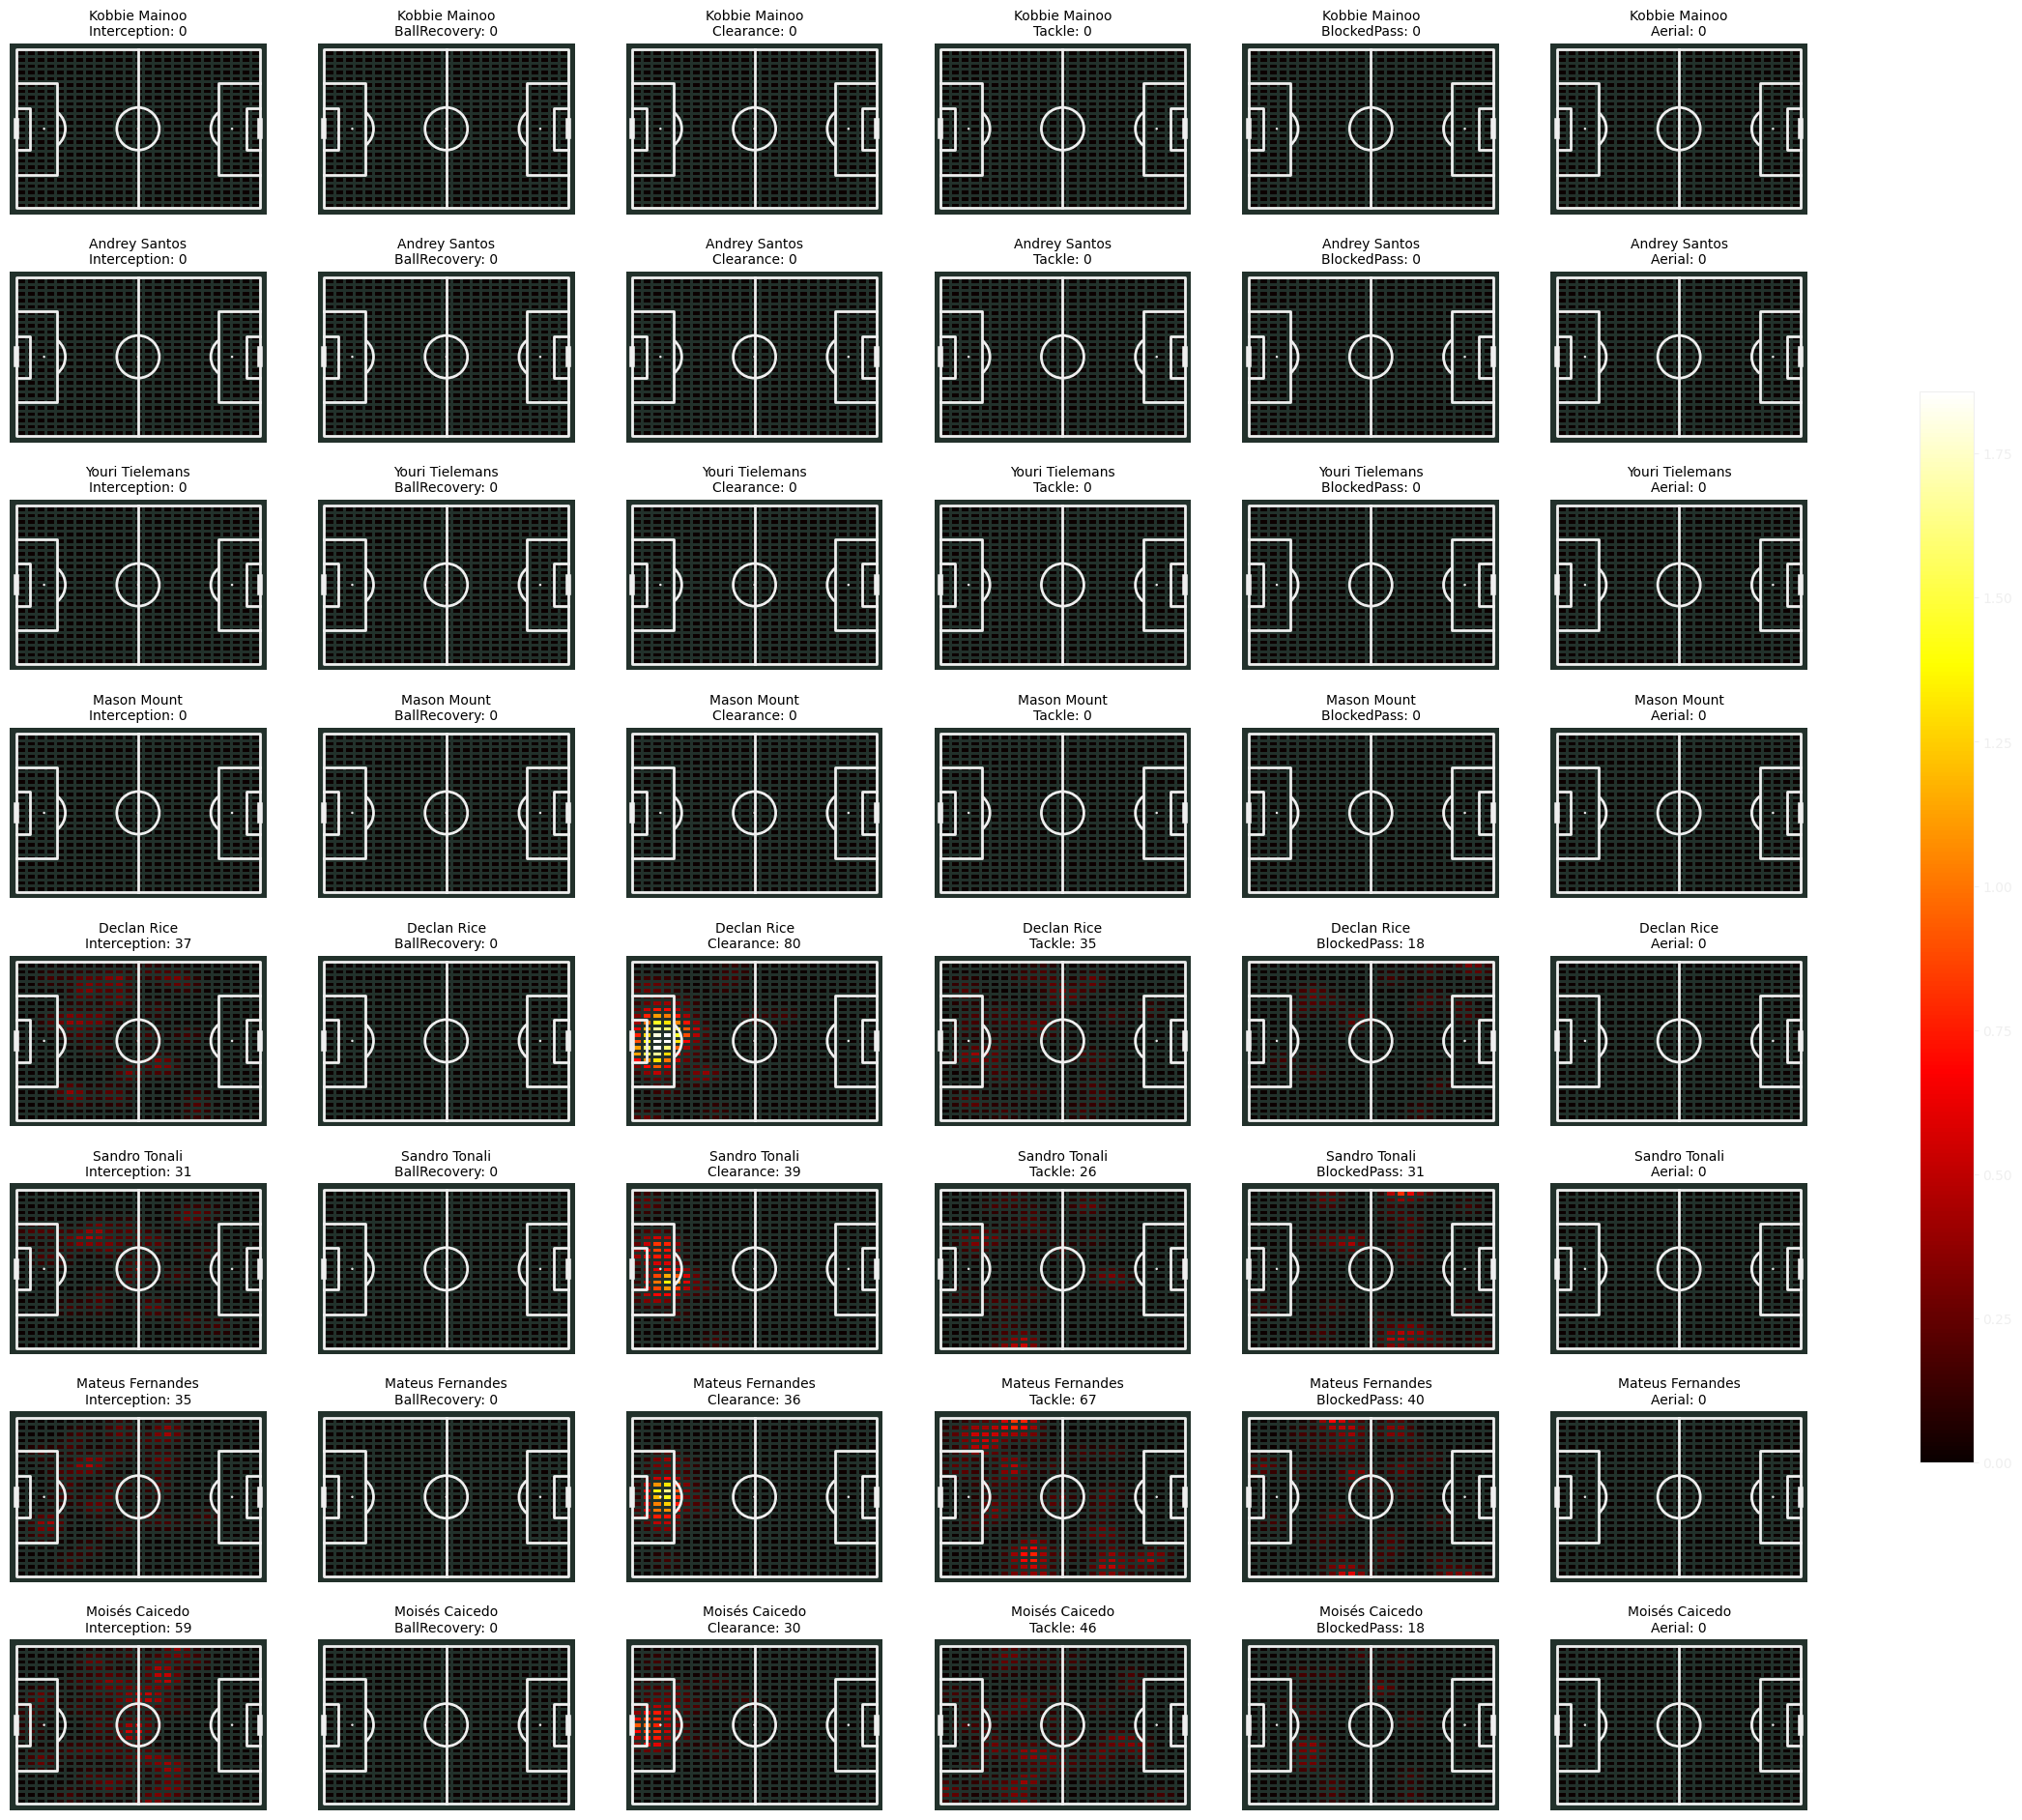

In [30]:
players = (
    "Kobbie Mainoo",
    "Andrey Santos",
    "Youri Tielemans",
    "Mason Mount",
    "Declan Rice",
    "Sandro Tonali",
    "Mateus Fernandes",
    "Moisés Caicedo"
)

def_actions = (
    "Interception",
    "BallRecovery",
    "Clearance",
    "Tackle",
    "BlockedPass",
    "Aerial"
    )

#pitch = VerticalPitch()


fig, axs = pitch.draw(
    nrows=len(players),
    ncols=len(def_actions),
    figsize=(30, 24),
    tight_layout=False,
    constrained_layout=True
)

# First calculate all heatmaps so they can share the same colour scale.
plot_data = []
global_max = 0

for row, player_name in enumerate(players):
    for col, action in enumerate(def_actions):
        player_action = player_events[
            player_events['player'].eq(player_name)
            & player_events['type'].eq(action)
        ]

        bin_statistic = pitch.bin_statistic(
            player_action['x'],
            player_action['y'],
            statistic='count',
            bins=(25, 25),
        )

        bin_statistic['statistic'] = gaussian_filter(
            bin_statistic['statistic'],
            sigma=1,
        )

        global_max = max(
            global_max,
            bin_statistic['statistic'].max(),
        )

        plot_data.append(
            (row, col, player_name, action, player_action, bin_statistic)
        )

# Prevent an invalid colour range if every chart is empty.
global_max = max(global_max, 1)

heatmaps = []

for (
    row,
    col,
    player_name,
    action,
    player_action,
    bin_statistic,
) in plot_data:

    axis = axs[row, col]

    pcm = pitch.heatmap(
        bin_statistic,
        ax=axis,
        cmap='hot',
        edgecolors='#22312b',
        vmin=0,
        vmax=global_max,
    )

    axis.set_title(
        f"{player_name}\n{action}: {len(player_action)}",
        color='black',
        fontsize=10,
    )

    heatmaps.append(pcm)

# One shared colour scale for all 24 charts.
cbar = fig.colorbar(
    heatmaps[-1],
    ax=axs.ravel().tolist(),
    shrink=0.6,
)

cbar.outline.set_edgecolor('#efefef')
cbar.ax.tick_params(colors='#efefef')

plt.show()

In [31]:
schedule = pd.read_csv("../data/raw/whoscored/WhoScored/ENG-Premier League/2025/ws_schedule.csv")



In [32]:



def_con = pd.read_csv("../data/processed/whoscored/ENG-Premier League/2025-2026/player_season/defense.csv")
#display(def_con)

print(def_con['position'].value_counts())
def_con['defcon'] = def_con['tackles_won'] + def_con['blocks'] + def_con['interceptions'] + def_con['clearances'] 

Unknown = def_con[def_con['position'].eq('UNK')].sort_values(by='defcon', ascending=False)
#display(Unknown)

df_defcon = def_con.copy()
df_defcon = df_defcon[df_defcon['fpl_pos'] != 'GKP']
df_defcon = df_defcon.dropna(subset='defcon')

mids = df_defcon[df_defcon['fpl_pos'].eq('MID')]
defs = df_defcon[df_defcon['fpl_pos'].eq('DEF')]
fwds = df_defcon[df_defcon['fpl_pos'].eq('FWD')]

#print(Unknown['matches_played'].value_counts())

display(df_defcon.sort_values(by='defcon', ascending=False))
display(f'Defenders def contribution', defs.sort_values(by='defcon', ascending=False))
display(f'Midfielders def contribution', mids.sort_values(by='defcon', ascending=False))
display(f"Forwards def contribution" , fwds.sort_values(by='defcon', ascending=False))


position
UNK    203
CB      92
FB      71
FW      70
W       55
DM      45
CM      42
AM      41
GK      39
WM       8
LWB      6
RWB      5
Name: count, dtype: int64


,league,season,provider_season,player_id,player,nation,born,position,primary_position,fpl_pos,fpl_position_source,fpl_position_confidence,matches_played,matches_covered,tackles,tackles_won,tackles_lost,dribbled_past,blocks,interceptions,clearances,errors,recoveries,defensive_aerials,provider,processing_version,metric_definition_version,metric_source_policy,coverage_status,defcon
352,ENG-Premier League,2025-2026,2025,7edccf6c,Marcos Senesi,ARG,1997.0,CB,CB,DEF,fpl.cleaned_players.fpl_pos,1.0,37,37,62.0,35.0,27.0,29.0,27.0,56.0,256.0,2.0,154.0,126.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,374.0
154,ENG-Premier League,2025-2026,2025,3aa7d48a,Maxence Lacroix,FRA,2000.0,CB,CB,DEF,fpl.cleaned_players.fpl_pos,1.0,35,36,60.0,38.0,22.0,11.0,25.0,45.0,261.0,3.0,94.0,119.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,369.0
591,ENG-Premier League,2025-2026,2025,d614da42,Virgil van Dijk,NED,1991.0,CB,CB,DEF,fpl.cleaned_players.fpl_pos,1.0,38,38,22.0,13.0,9.0,2.0,12.0,28.0,279.0,4.0,87.0,156.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,332.0
92,ENG-Premier League,2025-2026,2025,1ea0d01b,James Tarkowski,ENG,1992.0,CB,CB,DEF,fpl.cleaned_players.fpl_pos,1.0,37,37,51.0,29.0,22.0,13.0,17.0,32.0,242.0,8.0,88.0,104.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,320.0
165,ENG-Premier League,2025-2026,2025,3d3aac52,Chris Richards,USA,2000.0,CB,CB,DEF,fpl.cleaned_players.fpl_pos,1.0,33,34,55.0,35.0,20.0,18.0,24.0,43.0,204.0,4.0,65.0,131.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,306.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584,ENG-Premier League,2025-2026,2025,d356b467,Ashley Barnes,ENG,1989.0,UNK,UNK,FWD,fpl.cleaned_players.fpl_pos,1.0,6,18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0
285,ENG-Premier League,2025-2026,2025,643aca04,Ben Winterburn,ENG,2004.0,UNK,UNK,MID,fpl.cleaned_players.fpl_pos,1.0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0
632,ENG-Premier League,2025-2026,2025,e789ea19,Sean Neave,ENG,2007.0,UNK,UNK,FWD,fpl.cleaned_players.fpl_pos,1.0,1,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0
6,ENG-Premier League,2025-2026,2025,0281c792,Bendito Mantato,ENG,2008.0,UNK,UNK,MID,fpl.cleaned_players.fpl_pos,1.0,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0


'Defenders def contribution'

,league,season,provider_season,player_id,player,nation,born,position,primary_position,fpl_pos,fpl_position_source,fpl_position_confidence,matches_played,matches_covered,tackles,tackles_won,tackles_lost,dribbled_past,blocks,interceptions,clearances,errors,recoveries,defensive_aerials,provider,processing_version,metric_definition_version,metric_source_policy,coverage_status,defcon
352,ENG-Premier League,2025-2026,2025,7edccf6c,Marcos Senesi,ARG,1997.0,CB,CB,DEF,fpl.cleaned_players.fpl_pos,1.0,37,37,62.0,35.0,27.0,29.0,27.0,56.0,256.0,2.0,154.0,126.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,374.0
154,ENG-Premier League,2025-2026,2025,3aa7d48a,Maxence Lacroix,FRA,2000.0,CB,CB,DEF,fpl.cleaned_players.fpl_pos,1.0,35,36,60.0,38.0,22.0,11.0,25.0,45.0,261.0,3.0,94.0,119.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,369.0
591,ENG-Premier League,2025-2026,2025,d614da42,Virgil van Dijk,NED,1991.0,CB,CB,DEF,fpl.cleaned_players.fpl_pos,1.0,38,38,22.0,13.0,9.0,2.0,12.0,28.0,279.0,4.0,87.0,156.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,332.0
92,ENG-Premier League,2025-2026,2025,1ea0d01b,James Tarkowski,ENG,1992.0,CB,CB,DEF,fpl.cleaned_players.fpl_pos,1.0,37,37,51.0,29.0,22.0,13.0,17.0,32.0,242.0,8.0,88.0,104.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,320.0
165,ENG-Premier League,2025-2026,2025,3d3aac52,Chris Richards,USA,2000.0,CB,CB,DEF,fpl.cleaned_players.fpl_pos,1.0,33,34,55.0,35.0,20.0,18.0,24.0,43.0,204.0,4.0,65.0,131.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,306.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,ENG-Premier League,2025-2026,2025,9603dbe0,Tyler Fredricson,ENG,2005.0,UNK,UNK,DEF,fpl.cleaned_players.fpl_pos,1.0,1,11,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,2.0
66,ENG-Premier League,2025-2026,2025,15da165d,Emil Krafth,SWE,1994.0,FB,FB,DEF,fpl.cleaned_players.fpl_pos,1.0,1,10,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,1.0
219,ENG-Premier League,2025-2026,2025,4face18a,Jun'ai Byfield,ENG,2008.0,UNK,UNK,DEF,fpl.cleaned_players.fpl_pos,1.0,1,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0
367,ENG-Premier League,2025-2026,2025,821fa358,James Rowswell,ENG,2006.0,UNK,UNK,DEF,fpl.cleaned_players.fpl_pos,1.0,0,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0


'Midfielders def contribution'

,league,season,provider_season,player_id,player,nation,born,position,primary_position,fpl_pos,fpl_position_source,fpl_position_confidence,matches_played,matches_covered,tackles,tackles_won,tackles_lost,dribbled_past,blocks,interceptions,clearances,errors,recoveries,defensive_aerials,provider,processing_version,metric_definition_version,metric_source_policy,coverage_status,defcon
383,ENG-Premier League,2025-2026,2025,87cb7b87,James Garner,ENG,2001.0,DM,DM,MID,fpl.cleaned_players.fpl_pos,1.0,38,38,120.0,71.0,49.0,46.0,51.0,59.0,91.0,1.0,184.0,26.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,272.0
431,ENG-Premier League,2025-2026,2025,99355275,Ethan Ampadu,WAL,2000.0,CM,CM,MID,fpl.cleaned_players.fpl_pos,1.0,35,35,81.0,46.0,35.0,19.0,33.0,50.0,88.0,5.0,182.0,54.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,217.0
649,ENG-Premier League,2025-2026,2025,f17463ac,Casemiro,BRA,1992.0,DM,DM,MID,fpl.cleaned_players.fpl_pos,1.0,34,34,90.0,45.0,45.0,50.0,60.0,31.0,79.0,5.0,138.0,71.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,215.0
291,ENG-Premier League,2025-2026,2025,683b923f,Elliot Anderson,ENG,2002.0,DM,DM,MID,fpl.cleaned_players.fpl_pos,1.0,38,38,104.0,63.0,41.0,40.0,50.0,41.0,54.0,4.0,306.0,74.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,208.0
158,ENG-Premier League,2025-2026,2025,3bb5fbe3,Alex Scott,ENG,2003.0,DM,DM,MID,fpl.cleaned_players.fpl_pos,1.0,36,37,60.0,38.0,22.0,24.0,31.0,36.0,85.0,1.0,195.0,36.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,190.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,ENG-Premier League,2025-2026,2025,92fcfaf2,Jaydon Amauri Banel,NED,2004.0,UNK,UNK,MID,fpl.cleaned_players.fpl_pos,1.0,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0
638,ENG-Premier League,2025-2026,2025,ebddcd6b,Romelle Donovan,ENG,2006.0,UNK,UNK,MID,fpl.cleaned_players.fpl_pos,1.0,3,23,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,1.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0
639,ENG-Premier League,2025-2026,2025,ebf82e37,Divine Mukasa,ENG,2007.0,UNK,UNK,MID,fpl.cleaned_players.fpl_pos,1.0,2,11,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0
651,ENG-Premier League,2025-2026,2025,f3dc5354,George Hemmings,ENG,2007.0,UNK,UNK,MID,fpl.cleaned_players.fpl_pos,1.0,2,12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0


'Forwards def contribution'

,league,season,provider_season,player_id,player,nation,born,position,primary_position,fpl_pos,fpl_position_source,fpl_position_confidence,matches_played,matches_covered,tackles,tackles_won,tackles_lost,dribbled_past,blocks,interceptions,clearances,errors,recoveries,defensive_aerials,provider,processing_version,metric_definition_version,metric_source_policy,coverage_status,defcon
343,ENG-Premier League,2025-2026,2025,7b865b65,Jarrod Bowen,ENG,1996.0,WM,WM,FWD,fpl.cleaned_players.fpl_pos,1.0,38,38,50.0,29.0,21.0,26.0,25.0,27.0,40.0,1.0,159.0,31.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,121.0
54,ENG-Premier League,2025-2026,2025,11c3c63c,Thiago,BRA,2001.0,FW,FW,FWD,fpl.cleaned_players.fpl_pos,1.0,38,38,38.0,22.0,16.0,15.0,23.0,12.0,64.0,2.0,93.0,53.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,121.0
654,ENG-Premier League,2025-2026,2025,f49f1724,Richarlison,BRA,1997.0,FW,FW,FWD,fpl.cleaned_players.fpl_pos,1.0,32,33,27.0,16.0,11.0,12.0,11.0,5.0,52.0,1.0,61.0,47.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,84.0
299,ENG-Premier League,2025-2026,2025,6a6589fd,Raúl Jiménez,MEX,1991.0,FW,FW,FWD,fpl.cleaned_players.fpl_pos,1.0,36,36,35.0,21.0,14.0,19.0,12.0,8.0,31.0,1.0,55.0,52.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,72.0
598,ENG-Premier League,2025-2026,2025,d851d07b,Danny Welbeck,ENG,1990.0,FW,FW,FWD,fpl.cleaned_players.fpl_pos,1.0,37,37,24.0,14.0,10.0,13.0,14.0,9.0,32.0,2.0,51.0,19.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,69.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,ENG-Premier League,2025-2026,2025,19636c26,Odsonne Édouard,FRA,1998.0,UNK,UNK,FWD,fpl.cleaned_players.fpl_pos,1.0,1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,1.0
584,ENG-Premier League,2025-2026,2025,d356b467,Ashley Barnes,ENG,1989.0,UNK,UNK,FWD,fpl.cleaned_players.fpl_pos,1.0,6,18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0
632,ENG-Premier League,2025-2026,2025,e789ea19,Sean Neave,ENG,2007.0,UNK,UNK,FWD,fpl.cleaned_players.fpl_pos,1.0,1,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0
644,ENG-Premier League,2025-2026,2025,eec6db40,Kaye Furo,BEL,2007.0,UNK,UNK,FWD,fpl.cleaned_players.fpl_pos,1.0,1,13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,whoscored,1.2.0,1.2.0,aggregated_from_whoscored_match_tables,partial_or_complete_from_match_coverage,0.0


In [33]:
display(defs[['player', 'position', 'fpl_pos']])
display(fwds[['player', 'position', 'fpl_pos']])
display(mids[['player', 'position', 'fpl_pos']])

,player,position,fpl_pos
5,Ben Davies,FB,DEF
9,Malo Gusto,FB,DEF
10,Pascal Struijk,CB,DEF
12,John Stones,CB,DEF
14,Ki-Jana Hoever,RWB,DEF
...,...,...,...
664,Lucas Digne,FB,DEF
665,Borna Sosa,UNK,DEF
666,Luke Shaw,FB,DEF
667,Pedro Lima,RWB,DEF


,player,position,fpl_pos
3,Marc Guiu,FW,FWD
8,Arnaud Kalimuendo,UNK,FWD
17,Stefanos Tzimas,FW,FWD
18,Liam Delap,FW,FWD
37,Eliezer Mayenda,FW,FWD
...,...,...,...
642,Callum Wilson,FW,FWD
643,Dane Scarlett,UNK,FWD
644,Kaye Furo,UNK,FWD
654,Richarlison,FW,FWD


,player,position,fpl_pos
0,Phil Foden,CM,MID
1,Manuel Ugarte Ribeiro,DM,MID
2,Tawanda Chirewa,UNK,MID
6,Bendito Mantato,UNK,MID
7,Yéremy Pino,AM,MID
...,...,...,...
669,Patrick Roberts,UNK,MID
670,Joshua King,AM,MID
673,Kaoru Mitoma,W,MID
675,Guido Rodríguez,CM,MID


In [34]:
pos = pd.read_csv("../data/processed/whoscored/ENG-Premier League/2025-2026/player_match/defense.csv")

df_pos = pos.copy()

print(df_pos.shape)
mismatch = df_pos[df_pos['is_starter'].eq(1)]
print(mismatch.shape)
mismatch = mismatch[mismatch['position_group_match'] != mismatch['fpl_pos']]
print(mismatch.shape)


display(mismatch)
display(mismatch['player'].unique())

(15189, 55)
(8360, 55)
(1450, 55)


,league,season,provider_season,game,game_date,kickoff_utc,gameweek,match_id,provider_match_id,team_id,provider_team_id,team,provider_team_name,opponent_id,opponent,home,away,is_home,player_id,provider_player_id,player,provider_player_name,nation,born,age,provider_position_match,is_starter,position_detail_match,position_group_match,position,primary_position,fpl_pos,position_detail_match_imputed,position_source,position_confidence,position_imputation_source,fpl_position_source,fpl_position_confidence,shirt_no,minutes,tackles,tackles_won,tackles_lost,dribbled_past,blocks,interceptions,clearances,errors,recoveries,defensive_aerials,provider,processing_version,metric_definition_version,metric_source_policy,coverage_status
0,ENG-Premier League,2025-2026,2025,2025-08-15 Liverpool-Bournemouth,2025-08-15,2025-08-15 19:00:00+00:00,1,a071faa8,1903117,259f237e,26,LIV,Liverpool,56f0abca,BOU,LIV,BOU,True,1c2cd7dd,114147,Alisson,Alisson Becker,BRA,1992.0,33.0,GK,1,GK,GK,GK,GK,GKP,GK,whoscored.lineup,1.0,whoscored.match_position,fpl.cleaned_players.fpl_pos,1.0,1.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,whoscored,1.2.0,1.2.0,events_primary_match_stats_metadata,complete
2,ENG-Premier League,2025-2026,2025,2025-12-20 Leeds-Crystal Palace,2025-12-20,2025-12-20 20:00:00+00:00,17,a105af33,1903287,53c995cd,162,CRY,Crystal Palace,cd881c68,LEE,LEE,CRY,False,43b6d123,345845,Eddie Nketiah,Eddie Nketiah,ENG,1999.0,27.0,AMC,1,AM,MID,AM,AM,FWD,AM,whoscored.lineup,1.0,whoscored.match_position,fpl.cleaned_players.fpl_pos,1.0,9.0,76.0,2.0,2.0,0.0,1.0,1.0,0.0,5.0,0.0,2.0,1.0,whoscored,1.2.0,1.2.0,events_primary_match_stats_metadata,complete
5,ENG-Premier League,2025-2026,2025,2025-12-20 Everton-Arsenal,2025-12-20,2025-12-20 20:00:00+00:00,17,9bf2aba0,1903281,f5ee07af,31,EVE,Everton,1dd1f33c,ARS,EVE,ARS,True,b7f5d6fd,110189,Jordan Pickford,Jordan Pickford,ENG,1994.0,32.0,GK,1,GK,GK,GK,GK,GKP,GK,whoscored.lineup,1.0,whoscored.match_position,fpl.cleaned_players.fpl_pos,1.0,1.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,whoscored,1.2.0,1.2.0,events_primary_match_stats_metadata,complete
29,ENG-Premier League,2025-2026,2025,2026-03-22 Aston Villa-West Ham,2026-03-22,2026-03-22 14:15:00+00:00,31,3d4d50ca,1903461,bcc4ae28,24,AVL,Aston Villa,7fb5d771,WHU,AVL,WHU,True,5dfb108b,102248,Emiliano Martínez,Emiliano Martínez,ARG,1992.0,33.0,GK,1,GK,GK,GK,GK,GKP,GK,whoscored.lineup,1.0,whoscored.match_position,fpl.cleaned_players.fpl_pos,1.0,23.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,whoscored,1.2.0,1.2.0,events_primary_match_stats_metadata,complete
30,ENG-Premier League,2025-2026,2025,2025-12-20 Leeds-Crystal Palace,2025-12-20,2025-12-20 20:00:00+00:00,17,a105af33,1903287,53c995cd,162,CRY,Crystal Palace,cd881c68,LEE,LEE,CRY,False,63d000f4,304008,Dean Henderson,Dean Henderson,ENG,1997.0,29.0,GK,1,GK,GK,GK,GK,GKP,GK,whoscored.lineup,1.0,whoscored.match_position,fpl.cleaned_players.fpl_pos,1.0,1.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,whoscored,1.2.0,1.2.0,events_primary_match_stats_metadata,complete
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8342,ENG-Premier League,2025-2026,2025,2026-05-03 Bournemouth-Crystal Palace,2026-05-03,2026-05-03 13:00:00+00:00,35,d7832ab6,1903403,53c995cd,162,CRY,Crystal Palace,56f0abca,BOU,BOU,CRY,False,63d000f4,304008,Dean Henderson,Dean Henderson,ENG,1997.0,29.0,GK,1,GK,GK,GK,GK,GKP,GK,whoscored.lineup,1.0,whoscored.match_position,fpl.cleaned_players.fpl_pos,1.0,1.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,whoscored,1.2.0,1.2.0,events_primary_match_stats_metadata,complete
8345,ENG-Premier League,2025-2026,2025,2025-10-26 Wolves-Burnley,2025-10-26,2025-10-26 14:00:00+00:00,9,28244556,1903206,223048dd,161,WOL,Wolves,800d5085,BUR,WOL,BUR,True,2539a8a1,105603,Sam Johnstone,Sam Johnstone,ENG,1993.0,33.0,GK,1,GK,GK,GK,GK,GKP,GK,whoscored.lineup,1.0,wh

<ArrowStringArray>
[          'Alisson',     'Eddie Nketiah',   'Jordan Pickford',
 'Emiliano Martínez',    'Dean Henderson',         'Matz Sels',
        'David Raya',  'Leandro Trossard',       'Bukayo Saka',
       'Noah Okafor',
 ...
      'Rio Cardines', 'Kepa Arrizabalaga',  'Martín Zubimendi',
   'Bertrand Traoré',        'Lewis Cook',    'Luis Guilherme',
    'Jaidon Anthony',   'Freddie Woodman',      'Rayan Cherki',
     'Jack Harrison']
Length: 170, dtype: str